# 02a — Data Preparation & Feature Handling (v3)

**Dataset:** `essentia_newsamp.csv` — 294 tracks × 94 columns.

**What changed from v2 (bug fixes + principled design):**
- `is_danceable` threshold was wrong (0.5 cutoff, but values range 0.003–0.34). Fixed to median split.
- `energy_label` collapsed 100% of tracks to 'high energy' because `dynamic_complexity` is not 0–1. Fixed to tertile-based percentile threshold.
- `bpm_label` thresholds ignored actual BPM distribution (90–184, median 122). Fixed to quartile-based.
- `mood_relaxed`, `mood_sad`, `mood_acoustic` exceed 0.2 in 99–100% of tracks — useless as tags. Replaced AT moods with a smarter relative-surprise selection.
- Jamendo tags: instead of top-N by raw score (always returns classical/piano/folk), now uses **relative surprise** (score / dataset mean) to surface tags that are actually distinctive per track.
- MIREX: keeps all 5 values in the numeric vector; text description uses top-1 only with a confidence threshold.

**Structure:**
1. Load & inspect
2. Threshold analysis — justify every threshold with data
3. Feature selection — which features go in the numeric vector and why
4. Jamendo representation — surprise-weighted tags vs. fixed-column vector
5. MIREX representation — all-5 numeric vs. top-1 text tag
6. AT mood analysis — which mood columns are actually informative
7. Build the numeric feature matrix
8. Build text descriptions (using all fixes above)
9. Sanity checks — distributions of each label across the dataset
10. Save artifacts

---
## 0. Imports & Paths

In [ ]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 1. Load & Inspect

In [191]:
df = pd.read_csv("drive/MyDrive/GenAI/proj/essentia_newsamp.csv")
print(f'Shape: {df.shape}  ({df.shape[0]} tracks × {df.shape[1]} columns)')

print('\n=== Style breakdown ===')
print(df['style'].value_counts())

print('\n=== Decade breakdown ===')
print(df['decade'].value_counts().sort_index())
print(f'\nMissing year:   {df["year"].isna().sum()} / {len(df)}')
print(f'Missing decade: {df["decade"].isna().sum()} / {len(df)}')

print('\n=== Orchestras (top 10) ===')
print(df['orchestra'].value_counts().head(10))

Shape: (294, 94)  (294 tracks × 94 columns)

=== Style breakdown ===
style
tango      216
vals        41
milonga     37
Name: count, dtype: int64

=== Decade breakdown ===
decade
1920s      5
1930s     15
1940s    190
1950s     31
1960s     13
1970s      2
1990s      1
2000s      3
2010s      1
Name: count, dtype: int64

Missing year:   33 / 294
Missing decade: 33 / 294

=== Orchestras (top 10) ===
orchestra
Juan D'Arienzo        42
Anibal Troilo         37
Carlos Di Sarli       30
Ricardo Tanturi       27
Alfredo De Angelis    26
Angel D'Agostino      19
Osvaldo Pugliese      18
Osvaldo Fresedo       17
Pedro Laurenz         16
Francisco Canaro      16
Name: count, dtype: int64


---
## 2. Threshold Analysis

**Rule:** use percentile-based thresholds for features whose units are not 0–1.  
Use raw value or skip categorization for features already in [0,1].  
We derive all thresholds from the actual distribution here, then use them downstream.

### 2a. BPM — quartile bins

=== BPM distribution ===
count    294.00
mean     120.71
std       12.93
min       90.88
25%      112.31
50%      122.56
75%      126.50
max      184.57
Name: bpm, dtype: float64

Quartile thresholds (Q25/Q50/Q75): 112.31 / 122.56 / 126.50
Labels: slow | moderate | fast | very fast

Track count per BPM label:
bpm_label
fast         73
moderate     73
slow         74
very fast    74
Name: count, dtype: int64


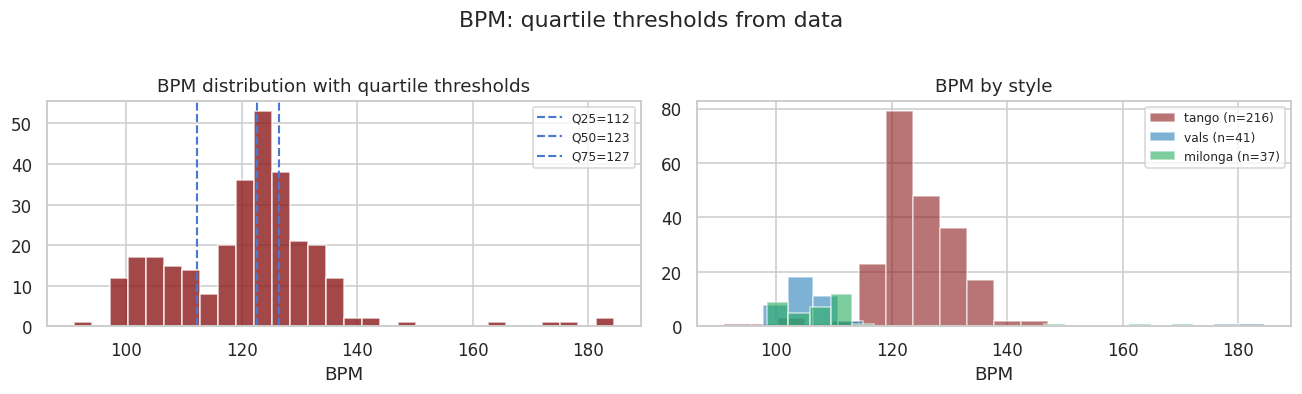

In [192]:
print('=== BPM distribution ===')
print(df['bpm'].describe().round(2))

BPM_Q = df['bpm'].quantile([0.25, 0.50, 0.75])
print(f'\nQuartile thresholds (Q25/Q50/Q75): {BPM_Q[0.25]:.2f} / {BPM_Q[0.50]:.2f} / {BPM_Q[0.75]:.2f}')
print('Labels: slow | moderate | fast | very fast')

# Create a new BPM label column without changing the original bpm column
def bpm_label(bpm):
    if bpm < BPM_Q[0.25]:
        return 'slow'
    if bpm < BPM_Q[0.50]:
        return 'moderate'
    if bpm < BPM_Q[0.75]:
        return 'fast'
    return 'very fast'

df['bpm_label'] = df['bpm'].apply(bpm_label)

print('\nTrack count per BPM label:')
print(df['bpm_label'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].hist(df['bpm'], bins=30, color='#8B1A1A', alpha=0.8, edgecolor='white')
for q_val, label in [(BPM_Q[0.25], 'Q25'), (BPM_Q[0.50], 'Q50'), (BPM_Q[0.75], 'Q75')]:
    axes[0].axvline(q_val, linestyle='--', linewidth=1.4, label=f'{label}={q_val:.0f}')
axes[0].set_title('BPM distribution with quartile thresholds')
axes[0].set_xlabel('BPM')
axes[0].legend(fontsize=8)

style_colors = {'tango': '#8B1A1A', 'vals': '#2980B9', 'milonga': '#27AE60'}
for style, color in style_colors.items():
    sub = df[df['style'] == style]['bpm']
    axes[1].hist(sub, bins=20, color=color, alpha=0.6, label=f'{style} (n={len(sub)})')
axes[1].set_title('BPM by style')
axes[1].set_xlabel('BPM')
axes[1].legend(fontsize=8)

plt.suptitle('BPM: quartile thresholds from data', y=1.02)
plt.tight_layout()
plt.show()

### 2b. Energy label — candidate correlation analysis, then composite

Several features could contribute to an 'energy' label:  
`dynamic_complexity`, `average_loudness`, `onset_rate`, `spectral_flux_mean`,  
`spectral_energy_mean`, `spectral_complexity_mean`, `jamendo_energetic`.  

**Before choosing which to use**, we check: how correlated are they with each other?  
Highly correlated candidates are redundant — including both adds noise, not signal.  
We want to either pick the best single feature, or build a composite from **independent** dimensions.

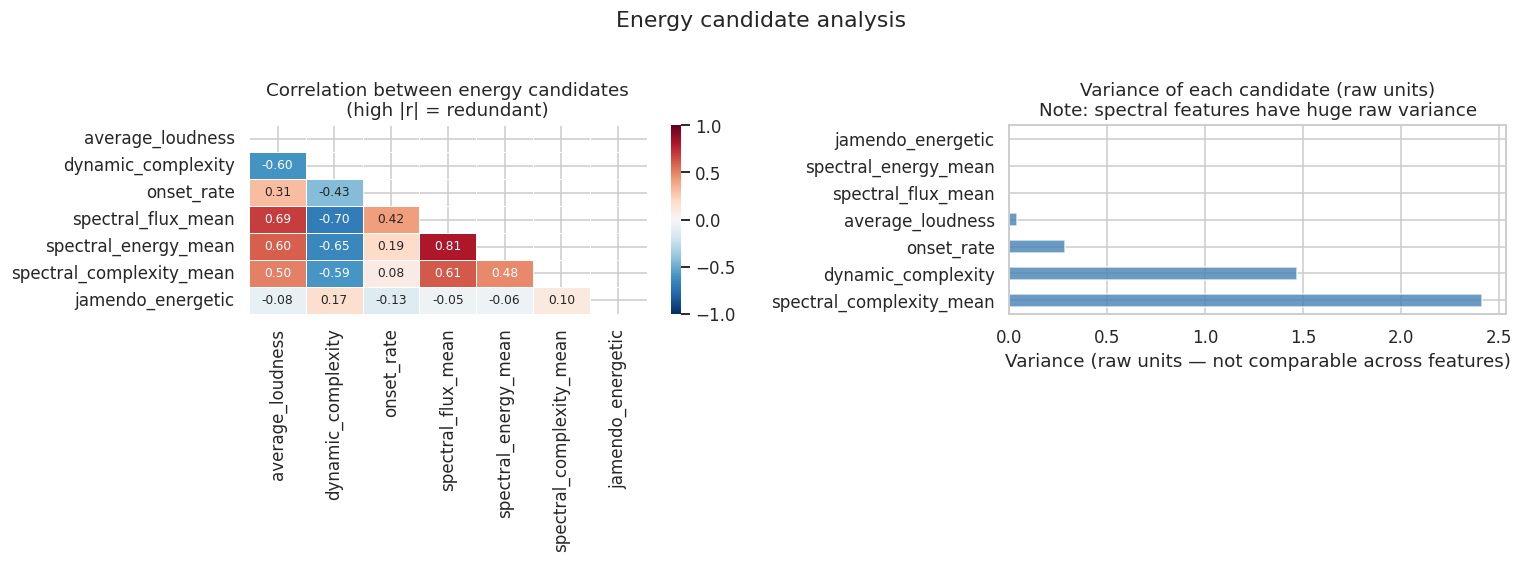

In [193]:
ENERGY_CANDIDATES = [
    'average_loudness',       # already [0,1]
    'dynamic_complexity',     # raw units ~2.8–10.8, NEGATIVELY correlated with loudness
    'onset_rate',             # rhythmic density — independent of loudness
    'spectral_flux_mean',     # temporal variation — highly correlated with loudness
    'spectral_energy_mean',   # raw energy — correlated with loudness
    'spectral_complexity_mean',
    'jamendo_energetic',      # classifier output [0,1]
]
ENERGY_CANDIDATES = [c for c in ENERGY_CANDIDATES if c in df.columns]

corr_e = df[ENERGY_CANDIDATES].corr().round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
import seaborn as sns
mask = np.triu(np.ones_like(corr_e, dtype=bool))
sns.heatmap(corr_e, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 8}, ax=axes[0])
axes[0].set_title('Correlation between energy candidates\n(high |r| = redundant)')

# Variance of each candidate (raw, before normalization)
var_e = df[ENERGY_CANDIDATES].var().sort_values(ascending=False)
var_e.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('Variance of each candidate (raw units)\nNote: spectral features have huge raw variance')
axes[1].set_xlabel('Variance (raw units — not comparable across features)')

plt.suptitle('Energy candidate analysis', y=1.02)
plt.tight_layout()
plt.show()

**Implications for energy composite:**

- `spectral_flux_mean` and `spectral_energy_mean` are dropped — they largely repeat what `average_loudness` already captures.
- `average_loudness` and `dynamic_complexity` pull in **opposite directions**: a uniformly loud track has low dynamic complexity, and vice versa. They measure different things — overall amplitude level vs. how dramatically the loudness varies. Both are kept, but complexity is **inverted** in the composite.
- `onset_rate` adds an independent rhythmic-density dimension and is included with a small weight.
- `jamendo_energetic` is independent of the others but has near-zero variance across this dataset (~0.0001). Though the scale might be a cause for small variance, scaling thing can be tricky and using other variables should be sufficient for energy representation.

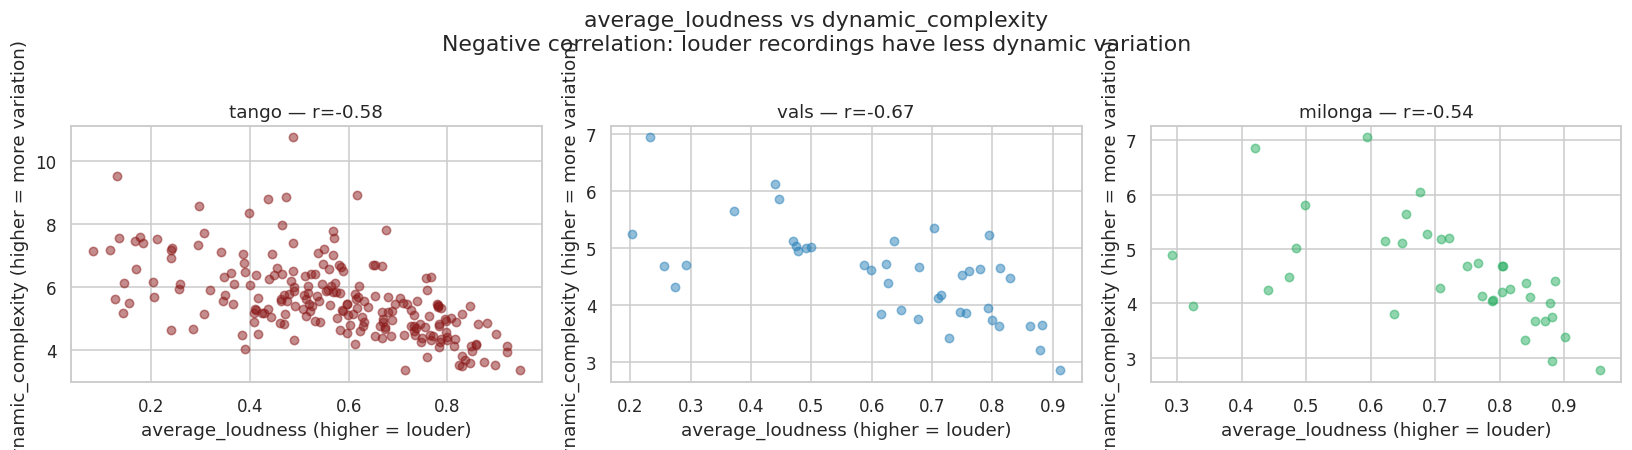

In [194]:
# ── Understand the dynamic_complexity vs loudness inversion ──────────────────
# r=-0.60 means: louder tracks tend to have LOWER dynamic_complexity.
# This makes physical sense: high dynamic_complexity = large swings in loudness
# (quiet passages vs loud peaks). Uniformly loud tracks have low complexity.
# So they measure DIFFERENT aspects of energy:
#   average_loudness    = overall amplitude level
#   dynamic_complexity  = loudness VARIATION (high = more expressive/dramatic)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, style, color in zip(
    axes, ['tango', 'vals', 'milonga'],
    ['#8B1A1A', '#2980B9', '#27AE60']
):
    sub = df[df['style'] == style]
    ax.scatter(sub['average_loudness'], sub['dynamic_complexity'],
               color=color, alpha=0.5, s=30)
    r = sub[['average_loudness','dynamic_complexity']].corr().iloc[0,1]
    ax.set_title(f'{style} — r={r:.2f}')
    ax.set_xlabel('average_loudness (higher = louder)')
    ax.set_ylabel('dynamic_complexity (higher = more variation)')

plt.suptitle('average_loudness vs dynamic_complexity\n'
             'Negative correlation: louder recordings have less dynamic variation',
             y=1.02)
plt.tight_layout()
plt.show()

In [195]:
# Build energy composite and tertile label
from sklearn.preprocessing import MinMaxScaler as _MMS

# Normalize each to [0,1] first so they contribute equally
_scaler = _MMS()
loudness_norm = _scaler.fit_transform(df[['average_loudness']]).flatten()
complexity_norm = _scaler.fit_transform(df[['dynamic_complexity']]).flatten()
onset_norm      = _scaler.fit_transform(df[['onset_rate']]).flatten()

`average_loudness` and `dynamic_complexity` are negatively correlated (r=−0.60). This is physically meaningful: a uniformly loud recording has low dynamic complexity because there are no quiet-to-loud swings. They pull in opposite directions, so dynamic_complexity enters the composite as (1 − complexity_norm) — meaning a track that is both loud and uniform scores high on both terms, which matches the intuition of "high energy" as a DJ would use it.

---
Rather than choosing arbitrary weights, we run PCA on the three normalized features and use PC1's loadings as weights. PC1 captures the dominant axis of joint variation.

In [196]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

X_energy = pd.DataFrame({
    'loudness':         loudness_norm,
    'inv_complexity':   1 - complexity_norm,
    'onset':            onset_norm,
})
pca_e = PCA(n_components=1)
pca_e.fit(X_energy)
w = pca_e.components_[0]
w = w / w.sum()  # normalize to sum to 1
print(f'PCA-derived weights: loudness={w[0]:.3f}, inv_complexity={w[1]:.3f}, onset={w[2]:.3f}')
energy_composite = pca_e.transform(X_energy).flatten()

PCA-derived weights: loudness=0.529, inv_complexity=0.291, onset=0.180


The weights are then normalized to sum to 1. The composite is a single scalar per track. We apply tertile bins (Q33/Q67) so that exactly ≈98 tracks fall in each of "low energy / moderate energy / high energy." This is purely for the text description — the three underlying features remain separate in the numeric vector.

In [197]:
# Build composite using PCA-derived weights
energy_composite = w[0]*loudness_norm + w[1]*(1 - complexity_norm) + w[2]*onset_norm
df['energy_composite'] = energy_composite

# Tertile bins
EC_Q = pd.Series(energy_composite).quantile([0.33, 0.67])
print(f'Tertile thresholds: Q33={EC_Q[0.33]:.3f}  Q67={EC_Q[0.67]:.3f}')

def energy_label(ec):
    if ec < EC_Q[0.33]: return 'low'
    if ec < EC_Q[0.67]: return 'moderate'
    return 'high'

# Two columns: raw composite value + category
df['energy_composite'] = energy_composite
df['energy_label'] = pd.Series(energy_composite).map(energy_label)

print('\nSample:')
print(df[['title', 'energy_composite', 'energy_label']].sample(5, random_state=42))

print('\nTrack count per energy label:')
print(df['energy_label'].value_counts())

Tertile thresholds: Q33=0.499  Q67=0.678

Sample:
                        title  energy_composite energy_label
33   Yo Me Llamo Eloy Peralta          0.783904         high
9            Del Tiempo Guapo          0.777159         high
146                La Morocha          0.464773          low
282          A La Gran Muñeca          0.317708          low
261                   Amurado          0.741747         high

Track count per energy label:
energy_label
moderate    100
low          97
high         97
Name: count, dtype: int64


### 2c. `is_danceable` — median split

This is Essentia's binary danceability output, but stored as a float in range [0.003, 0.34].  
The 0.5 threshold from v2 put **0/294 tracks** in 'danceable'. Fixed to median split.

=== is_danceable distribution ===
count    294.0000
mean       0.0566
std        0.0551
min        0.0034
25%        0.0198
50%        0.0410
75%        0.0710
max        0.3355
Name: is_danceable, dtype: float64

Median: 0.0410
Tracks above median: 147 / 294

=== danceability (Essentia continuous score — different field) ===
count    294.000
mean       1.022
std        0.079
min        0.835
25%        0.967
50%        1.024
75%        1.071
max        1.310
Name: danceability, dtype: float64


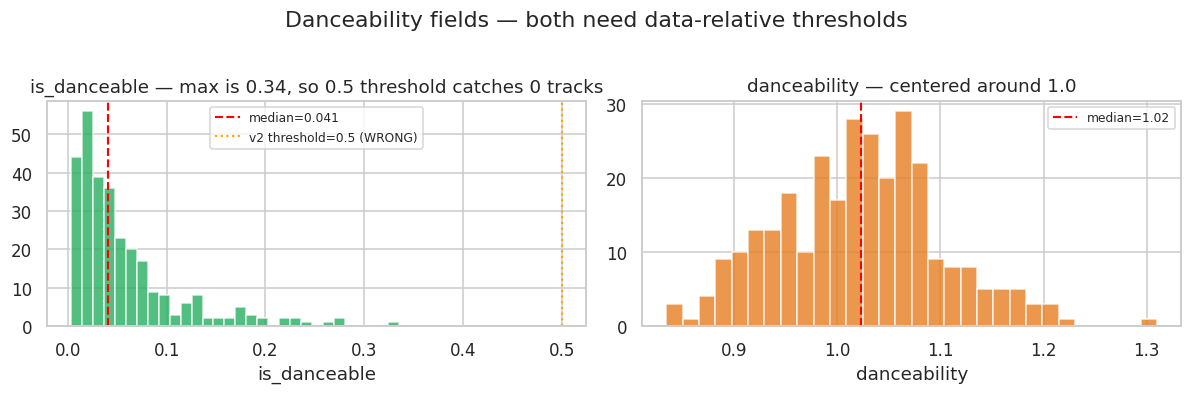

In [198]:
print('=== is_danceable distribution ===')
print(df['is_danceable'].describe().round(4))

IS_DANCE_MED = df['is_danceable'].median()
print(f'\nMedian: {IS_DANCE_MED:.4f}')
print(f'Tracks above median: {(df["is_danceable"] > IS_DANCE_MED).sum()} / {len(df)}')

# Also show Essentia danceability (different field, centered ~1.0)
print('\n=== danceability (Essentia continuous score — different field) ===')
print(df['danceability'].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].hist(df['is_danceable'], bins=30, color='#27AE60', alpha=0.8, edgecolor='white')
axes[0].axvline(IS_DANCE_MED, color='red', linestyle='--', linewidth=1.4,
                label=f'median={IS_DANCE_MED:.3f}')
axes[0].axvline(0.5, color='orange', linestyle=':', linewidth=1.4, label='v2 threshold=0.5 (WRONG)')
axes[0].set_title('is_danceable — max is 0.34, so 0.5 threshold catches 0 tracks')
axes[0].set_xlabel('is_danceable')
axes[0].legend(fontsize=8)

axes[1].hist(df['danceability'], bins=30, color='#E67E22', alpha=0.8, edgecolor='white')
axes[1].axvline(df['danceability'].median(), color='red', linestyle='--', linewidth=1.4,
                label=f'median={df["danceability"].median():.2f}')
axes[1].set_title('danceability — centered around 1.0')
axes[1].set_xlabel('danceability')
axes[1].legend(fontsize=8)

plt.suptitle('Danceability fields — both need data-relative thresholds', y=1.02)
plt.tight_layout()
plt.show()

def danceable_label(is_dance_val):
    return 'danceable' if is_dance_val > IS_DANCE_MED else 'subtly danceable'

In [199]:
r = df[['is_danceable', 'danceability']].corr().iloc[0,1]
print(f'r(is_danceable, danceability) = {r:.3f}')

r(is_danceable, danceability) = 0.045


We will use `danceability` with tertile bins as it has a proper bell-shaped distribution that splits meaningfully. Drop `is_danceable` from the text label entirely since its skewed distribution makes any threshold arbitrary.

In [200]:
# Keep original numeric danceability, and also create another new columns:
# danceability_label -> tertile-based text label

DANCE_Q = df['danceability'].quantile([0.33, 0.67])

def danceable_label(val):
    if val < DANCE_Q[0.33]:
        return 'low'
    if val < DANCE_Q[0.67]:
        return 'moderate'
    return 'high'

df['danceability_label'] = df['danceability'].apply(danceable_label)

print('\nDistribution (should be ~33% each):')
print(df['danceability_label'].value_counts())


Distribution (should be ~33% each):
danceability_label
moderate    100
high         97
low          97
Name: count, dtype: int64


---
### 2d. Jamendo Representation Analysis

In [201]:
jamendo_cols = [c for c in df.columns if c.startswith('jamendo_')]
j = df[jamendo_cols].astype(float)

# ── Three metrics per tag ─────────────────────────────────────────────────────
jamendo_stats = pd.DataFrame({
    'mean':     j.mean(),
    'std':      j.std(),
    'variance': j.var(),
    # Coefficient of variation: std/mean — how much does it vary RELATIVE to its average?
    # High CV = tag is discriminating between tracks
    # Low CV  = tag fires at roughly the same level on every track (useless)
    'cv':       j.std() / (j.mean() + 1e-9),
    # What fraction of tracks score above a meaningful threshold?
    # Tags where pct_active ~ 0% or ~100% carry no information
    'pct_active': (j > 0.05).mean(),
}).sort_values('cv', ascending=False)

jamendo_stats = jamendo_stats.rename(index=lambda x: x.replace('jamendo_', ''))

print('=== All Jamendo tags ranked by Coefficient of Variation ===')
print('(CV = std/mean — higher = more discriminating between tracks)')
print()
print(jamendo_stats.round(4).to_string())

=== All Jamendo tags ranked by Coefficient of Variation ===
(CV = std/mean — higher = more discriminating between tracks)

                   mean     std  variance      cv  pct_active
reggae           0.0232  0.0224    0.0005  0.9654      0.0782
orchestral       0.0380  0.0288    0.0008  0.7567      0.1973
strings          0.0196  0.0125    0.0002  0.6400      0.0340
soundtrack       0.0541  0.0338    0.0011  0.6244      0.4150
jazz             0.0346  0.0195    0.0004  0.5651      0.1701
emotional        0.0066  0.0036    0.0000  0.5449      0.0000
downtempo        0.0014  0.0007    0.0000  0.5202      0.0000
atmospheric      0.0024  0.0012    0.0000  0.5126      0.0000
triphop          0.0019  0.0010    0.0000  0.5046      0.0000
funk             0.0024  0.0012    0.0000  0.4951      0.0000
house            0.0022  0.0011    0.0000  0.4920      0.0000
film             0.0190  0.0093    0.0001  0.4903      0.0170
newage           0.0068  0.0033    0.0000  0.4877      0.0000
electricg

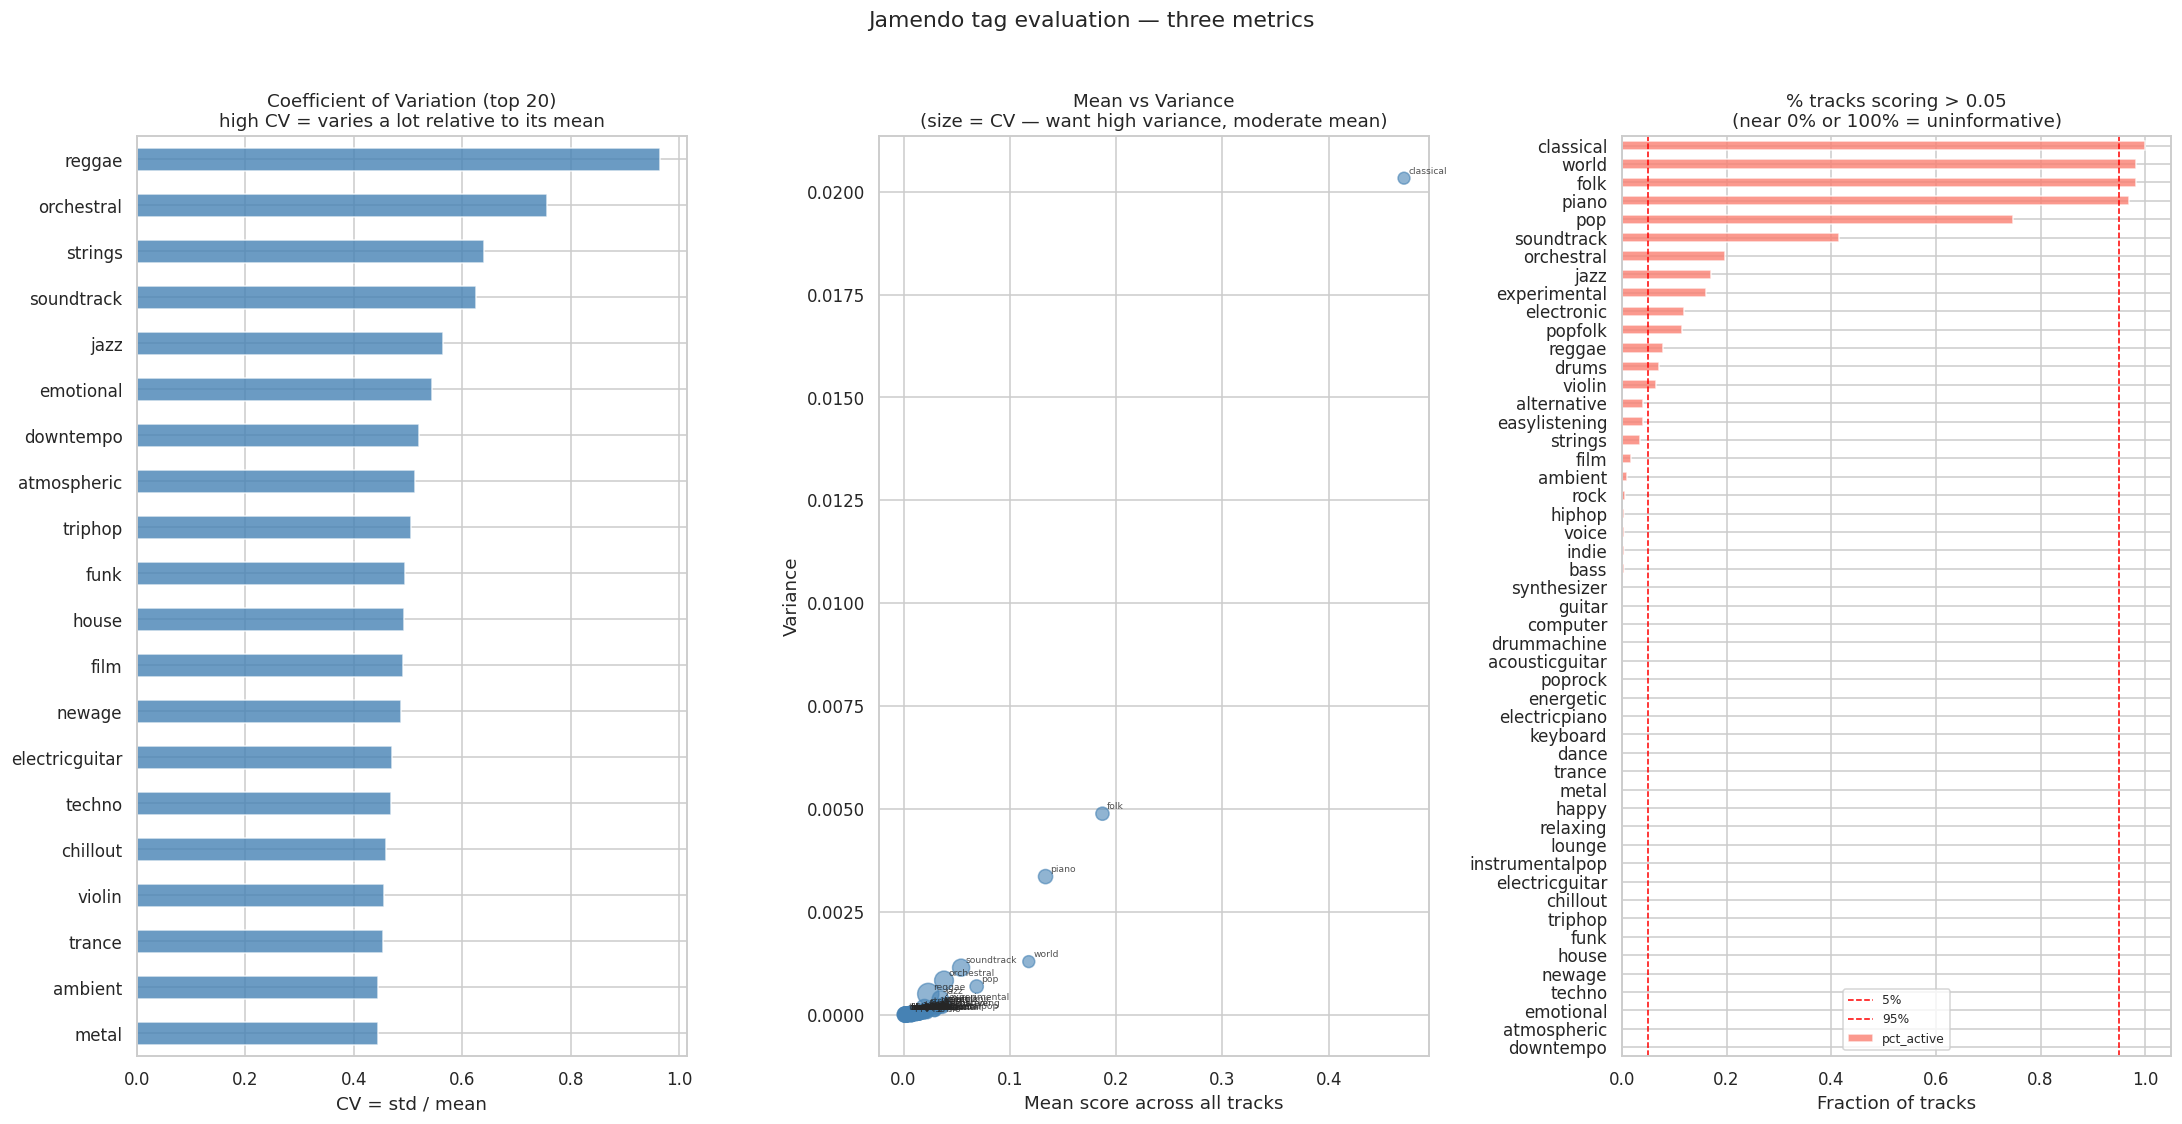

In [202]:
# ── Plot: variance vs mean, sized by CV ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# 1. CV bar chart — most discriminating tags
jamendo_stats['cv'].head(20).sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('Coefficient of Variation (top 20)\nhigh CV = varies a lot relative to its mean')
axes[0].set_xlabel('CV = std / mean')

# 2. Mean vs variance scatter — annotate each point
ax = axes[1]
ax.scatter(jamendo_stats['mean'], jamendo_stats['variance'],
           s=jamendo_stats['cv']*200, alpha=0.6, color='steelblue')
for tag, row in jamendo_stats.iterrows():
    ax.annotate(tag, (row['mean'], row['variance']),
                fontsize=6, alpha=0.8,
                xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Mean score across all tracks')
ax.set_ylabel('Variance')
ax.set_title('Mean vs Variance\n(size = CV — want high variance, moderate mean)')

# 3. pct_active — what fraction of tracks does this tag fire on?
# Tags near 0% or 100% are uninformative
jamendo_stats['pct_active'].sort_values().plot(
    kind='barh', ax=axes[2], color='salmon', alpha=0.8)
axes[2].axvline(0.05, color='red',   linestyle='--', linewidth=1, label='5%')
axes[2].axvline(0.95, color='red',   linestyle='--', linewidth=1, label='95%')
axes[2].set_title('% tracks scoring > 0.05\n(near 0% or 100% = uninformative)')
axes[2].set_xlabel('Fraction of tracks')
axes[2].legend(fontsize=8)

plt.suptitle('Jamendo tag evaluation — three metrics', y=1.02)
plt.tight_layout()
plt.show()

In [203]:
JAMENDO_KEEP = jamendo_stats[
    (jamendo_stats['pct_active'] > 0.01) &
    (jamendo_stats['pct_active'] < 0.80) &
    (jamendo_stats['cv']         > 0.40)
].sort_values('cv', ascending=False).index.tolist()

print(f'Tags kept: {len(JAMENDO_KEEP)}')
print(jamendo_stats.loc[JAMENDO_KEEP].sort_values('cv', ascending=False).round(4).to_string())

Tags kept: 11
                mean     std  variance      cv  pct_active
reggae        0.0232  0.0224    0.0005  0.9654      0.0782
orchestral    0.0380  0.0288    0.0008  0.7567      0.1973
strings       0.0196  0.0125    0.0002  0.6400      0.0340
soundtrack    0.0541  0.0338    0.0011  0.6244      0.4150
jazz          0.0346  0.0195    0.0004  0.5651      0.1701
film          0.0190  0.0093    0.0001  0.4903      0.0170
violin        0.0307  0.0140    0.0002  0.4548      0.0646
ambient       0.0217  0.0096    0.0001  0.4451      0.0102
drums         0.0307  0.0133    0.0002  0.4335      0.0714
popfolk       0.0336  0.0141    0.0002  0.4209      0.1156
experimental  0.0375  0.0156    0.0002  0.4157      0.1599


CV and pct_active together catch two opposite failure modes. CV (std/mean) measures how much a tag varies relative to its own average — a tag like classical has high absolute variance but low CV (0.30) because it fires at a consistently high level on nearly every track, so it doesn't tell you much about any individual song. pct_active catches what CV misses at the extremes: tags that fire on 97–100% of tracks (like classical, folk, piano) are near-constants that can't discriminate between songs, while tags that fire on 0% of tracks are pure noise. Together the two filters keep only tags that are genuinely sometimes present and sometimes absent — which is exactly what makes a feature useful for retrieval and similarity

In [204]:
JAMENDO_KEEP = [
    'jamendo_reggae', 'jamendo_orchestral', 'jamendo_strings', 'jamendo_soundtrack',
    'jamendo_jazz', 'jamendo_film', 'jamendo_violin', 'jamendo_ambient',
    'jamendo_drums', 'jamendo_popfolk', 'jamendo_experimental'
]

# Q75: "this track scores higher than 75% of the catalog on this tag"
JAMENDO_Q75 = {col: df[col].quantile(0.75) for col in JAMENDO_KEEP}

def jamendo_text_tags(row):
    """Tags where this track scores above the 75th percentile.
    Returns 0–11 tags naturally — no fixed top-N cutoff.
    Tracks with zero tags simply get no jamendo descriptor in the text.
    """
    return [
        col.replace('jamendo_', '')
        for col in JAMENDO_KEEP
        if row[col] > JAMENDO_Q75[col]
    ]

df['jamendo_tags'] = df.apply(jamendo_text_tags, axis=1)

In [205]:
# Spot check
print(f'Mean tags per track: {df["jamendo_tags"].apply(len).mean():.1f}')
print(f'Tracks with 0 tags:  {(df["jamendo_tags"].apply(len) == 0).sum()}')
print()

for i in [0, 30, 60, 100, 150, 200]:
    row = df.iloc[i]
    print(f'[{row["style"]}] {row["title"][:35]:<35} → {row["jamendo_tags"]}')

Mean tags per track: 2.8
Tracks with 0 tags:  57

[milonga] Asi Me Gusta A Mi                   → []
[milonga] La Mañana                           → ['reggae']
[vals] Desde El Alma                       → []
[tango] El Incendio                         → ['strings', 'soundtrack', 'drums', 'experimental']
[tango] Un Lamento                          → ['jazz', 'ambient', 'drums', 'experimental']
[tango] No Nos Veremos Mas                  → ['orchestral', 'strings', 'soundtrack', 'jazz', 'film', 'violin', 'ambient', 'drums', 'popfolk']


---
### 2e. MIREX Representation Analysis

In [206]:
print([c for c in df.columns if c.startswith("mirex_")])

['mirex_mood_passionate_rousing_confident_boisterous_rowdy', 'mirex_mood_rollicking_cheerful_fun_sweet_amiable_good_natured', 'mirex_mood_literate_poignant_wistful_bittersweet_autumnal_brooding', 'mirex_mood_humorous_silly_campy_quirky_whimsical_witty_wry', 'mirex_mood_aggressive_fiery_tense_anxious_intense_volatile_visceral']


In [207]:
MIREX_COLS = [c for c in df.columns if c.startswith('mirex_')]

def mirex_tags(row):
    """Return the top-1 MIREX cluster as a list of its component words.
    No threshold — every track gets exactly one MIREX tag list.
    """
    top_col = row[MIREX_COLS].idxmax()
    words = top_col.replace('mirex_mood_', '').split('_')
    return words

df['mirex_tags'] = df.apply(mirex_tags, axis=1)

# Spot check
for i in [0, 30, 60, 100, 150]:
    row = df.iloc[i]
    print(f'[{row["style"]}] {row["title"][:35]:<35} → {row["mirex_tags"]}')

print()
print('=== Top-1 MIREX cluster distribution ===')
top1 = df[MIREX_COLS].idxmax(axis=1).str.replace('mirex_mood_','').str.split('_').str[0]
print(top1.value_counts())

[milonga] Asi Me Gusta A Mi                   → ['humorous', 'silly', 'campy', 'quirky', 'whimsical', 'witty', 'wry']
[milonga] La Mañana                           → ['rollicking', 'cheerful', 'fun', 'sweet', 'amiable', 'good', 'natured']
[vals] Desde El Alma                       → ['rollicking', 'cheerful', 'fun', 'sweet', 'amiable', 'good', 'natured']
[tango] El Incendio                         → ['rollicking', 'cheerful', 'fun', 'sweet', 'amiable', 'good', 'natured']
[tango] Un Lamento                          → ['literate', 'poignant', 'wistful', 'bittersweet', 'autumnal', 'brooding']

=== Top-1 MIREX cluster distribution ===
rollicking    135
literate      124
humorous       35
Name: count, dtype: int64


---
###2f. AT Mood Analysis

Seven `mood_*` columns from Essentia's mood classifiers. Before deciding what to do with them,
we need to understand three things:
1. Which columns have meaningful variance (CV analysis, same method as Jamendo)
2. Which are correlated with each other (redundancy)
3. Whether they differ across styles (tango vs vals vs milonga) — if not, they won't help retrieval

Then we decide: keep raw in numeric vector / engineer derived features / use in text description.

In [208]:
print([c for c in df.columns if c.startswith("mood_")])

['mood_happy', 'mood_sad', 'mood_relaxed', 'mood_aggressive', 'mood_party', 'mood_acoustic', 'mood_electronic']


In [209]:
mood_cols = [c for c in df.columns if c.startswith('mood_')]

mood_stats = pd.DataFrame({
    'mean':         df[mood_cols].mean(),
    'std':          df[mood_cols].std(),
    'cv':           df[mood_cols].std() / (df[mood_cols].mean() + 1e-9),
    'pct_above_0.2': (df[mood_cols] > 0.2).mean(),
    'pct_above_0.5': (df[mood_cols] > 0.5).mean(),
}).rename(index=lambda x: x.replace('mood_', ''))

print('=== Mood column stats ===')
print(mood_stats.round(3).to_string())

=== Mood column stats ===
             mean    std     cv  pct_above_0.2  pct_above_0.5
happy       0.365  0.142  0.389          0.881          0.201
sad         0.569  0.183  0.321          0.986          0.629
relaxed     0.859  0.109  0.127          1.000          0.997
aggressive  0.010  0.005  0.455          0.000          0.000
party       0.077  0.067  0.864          0.048          0.000
acoustic    0.587  0.151  0.258          0.986          0.741
electronic  0.077  0.066  0.859          0.068          0.000


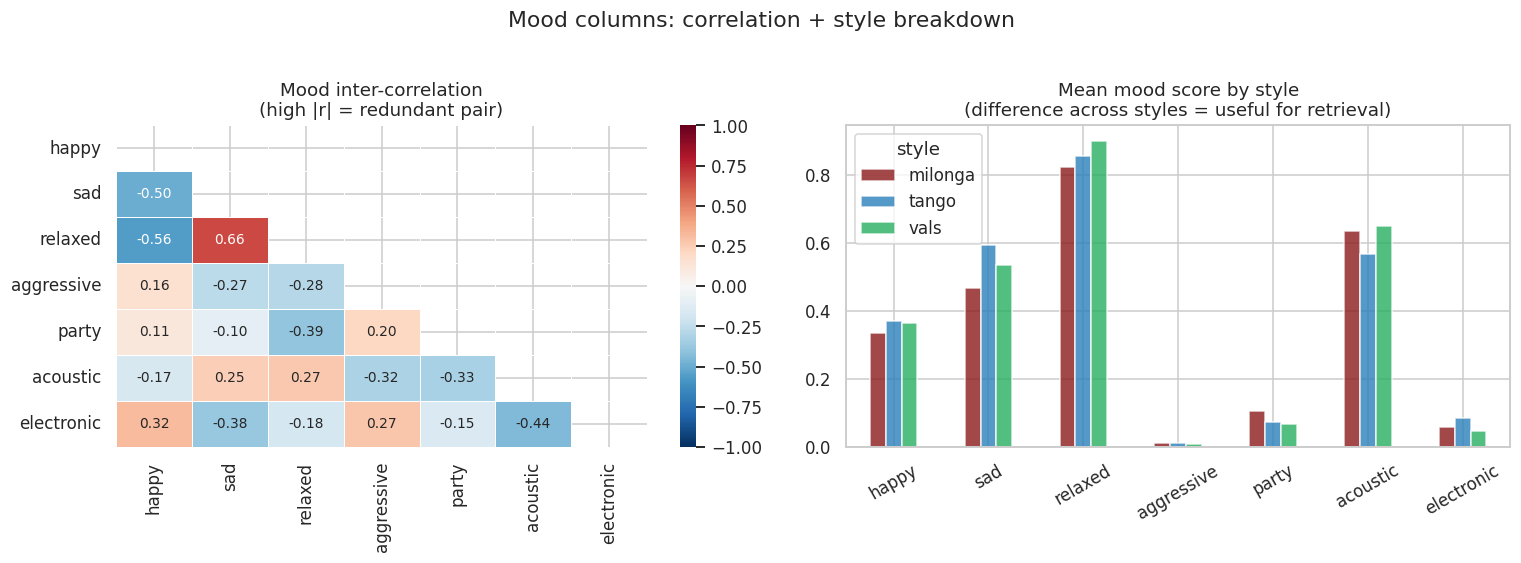

In [210]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
corr_mood = df[mood_cols].corr()
mask = np.triu(np.ones_like(corr_mood, dtype=bool))
sns.heatmap(corr_mood, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9}, ax=axes[0],
            xticklabels=[c.replace('mood_','') for c in mood_cols],
            yticklabels=[c.replace('mood_','') for c in mood_cols])
axes[0].set_title('Mood inter-correlation\n(high |r| = redundant pair)')

# Mean by style
style_mood = df.groupby('style')[mood_cols].mean().rename(columns=lambda x: x.replace('mood_',''))
style_mood.T.plot(kind='bar', ax=axes[1],
                  color=['#8B1A1A', '#2980B9', '#27AE60'], alpha=0.8)
axes[1].set_title('Mean mood score by style\n(difference across styles = useful for retrieval)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='style')

plt.suptitle('Mood columns: correlation + style breakdown', y=1.02)
plt.tight_layout()
plt.show()

In [211]:
# Just keep the two columns with real variance and meaningful sparsity
# Drop everything else from the mood group

MOOD_NUMERIC = [
    'mood_sad',         # varies meaningfully, differs across styles
    'mood_happy',       # partially independent of sad (r=-0.50)
    'mood_party',       # sparse but informative
    'mood_electronic',  # sparse but informative
]

In [212]:
# For each mood col we're considering as a text tag,
# print the distribution and candidate thresholds

for col in MOOD_NUMERIC:
    vals = df[col]
    print(f'=== {col} ===')
    print(f'  mean={vals.mean():.3f}  std={vals.std():.3f}  '
          f'min={vals.min():.3f}  max={vals.max():.3f}')
    print(f'  percentiles:')
    for p in [0.50, 0.60, 0.70, 0.75, 0.80, 0.90]:
        pct_val = vals.quantile(p)
        n_above = (vals > pct_val).sum()
        print(f'    Q{int(p*100)}: {pct_val:.3f}  →  {n_above} tracks ({n_above/len(df):.0%}) get this tag')
    print()

=== mood_sad ===
  mean=0.569  std=0.183  min=0.095  max=0.906
  percentiles:
    Q50: 0.571  →  147 tracks (50%) get this tag
    Q60: 0.645  →  118 tracks (40%) get this tag
    Q70: 0.691  →  88 tracks (30%) get this tag
    Q75: 0.720  →  74 tracks (25%) get this tag
    Q80: 0.748  →  59 tracks (20%) get this tag
    Q90: 0.814  →  30 tracks (10%) get this tag

=== mood_happy ===
  mean=0.365  std=0.142  min=0.065  max=0.784
  percentiles:
    Q50: 0.354  →  147 tracks (50%) get this tag
    Q60: 0.393  →  118 tracks (40%) get this tag
    Q70: 0.443  →  88 tracks (30%) get this tag
    Q75: 0.467  →  74 tracks (25%) get this tag
    Q80: 0.495  →  59 tracks (20%) get this tag
    Q90: 0.551  →  30 tracks (10%) get this tag

=== mood_party ===
  mean=0.077  std=0.067  min=0.002  max=0.411
  percentiles:
    Q50: 0.058  →  147 tracks (50%) get this tag
    Q60: 0.075  →  118 tracks (40%) get this tag
    Q70: 0.098  →  88 tracks (30%) get this tag
    Q75: 0.113  →  74 tracks (25%)

In [213]:
# Using Q75 values as thresholds

MOOD_TEXT_RULES = [
    ('mood_sad',        0.720, 'sad'),
    ('mood_happy',      0.467, 'happy'),
    ('mood_party',      0.113, 'party'),
    ('mood_electronic', 0.102, 'electronic'),
    # mood_relaxed, mood_acoustic, mood_aggressive excluded
]

def mood_text_tags(row):
    return [label for col, thresh, label in MOOD_TEXT_RULES
            if row[col] > thresh]

df['mood_tags'] = df.apply(mood_text_tags, axis=1)

## 3. Harmony / tonality feature investigation

In [214]:
# 1. Basic stats on numeric ones
harmony_numeric = ['key_strength', 'chords_changes_rate', 'chords_number_rate']

print('=== Numeric harmony feature stats ===')
print(df[harmony_numeric].describe().round(3).to_string())

print('\n=== CV ===')
cv = df[harmony_numeric].std() / (df[harmony_numeric].mean() + 1e-9)
print(cv.round(3))

print('\n=== Correlation with each other ===')
print(df[harmony_numeric].corr().round(3).to_string())

# 2. key and scale are categorical — check distributions
print('\n=== key distribution ===')
print(df['key'].value_counts())

print('\n=== scale distribution ===')
print(df['scale'].value_counts())

# 3. Do harmony features differ by style? (main question for retrieval usefulness)
print('\n=== Numeric harmony means by style ===')
print(df.groupby('style')[harmony_numeric].mean().round(4).to_string())

print('\n=== key by style ===')
print(pd.crosstab(df['style'], df['key']))

print('\n=== scale by style ===')
print(pd.crosstab(df['style'], df['scale']))

# 4. Does key_strength correlate with anything musically meaningful?
print('\n=== key_strength correlation with other features ===')
numeric_cols = df.select_dtypes(include='number').columns
corr_ks = df[numeric_cols].corrwith(df['key_strength']).abs().sort_values(ascending=False)
print(corr_ks.head(15).round(3))

=== Numeric harmony feature stats ===
       key_strength  chords_changes_rate  chords_number_rate
count       294.000              294.000             294.000
mean          0.754                0.068               0.004
std           0.072                0.015               0.001
min           0.525                0.032               0.002
25%           0.714                0.059               0.003
50%           0.765                0.069               0.004
75%           0.803                0.078               0.004
max           0.909                0.111               0.006

=== CV ===
key_strength           0.095
chords_changes_rate    0.217
chords_number_rate     0.232
dtype: float64

=== Correlation with each other ===
                     key_strength  chords_changes_rate  chords_number_rate
key_strength                1.000               -0.204              -0.347
chords_changes_rate        -0.204                1.000               0.573
chords_number_rate         -0.347    

In [215]:
KEY_THRESH = 0.5

df["key_used"] = df["key"].where(df["key_strength"] > KEY_THRESH)

print("Counts per key (with NA):")
print(df["key_used"].value_counts(dropna=False))

print("\nNA count:")
print(df["key_used"].isna().sum())

Counts per key (with NA):
key_used
D     59
G     46
C     36
F     36
A     34
E     28
B     21
C#    10
Bb     9
Eb     7
F#     7
Ab     1
Name: count, dtype: int64

NA count:
0


In [218]:
# chords_changes_rate_label -> tertile-based text label

CHORDS_CHANGE_Q = df['chords_changes_rate'].quantile([0.33, 0.67])

def chords_label(val):
    if val < CHORDS_CHANGE_Q[0.33]:
        return 'low'
    if val < CHORDS_CHANGE_Q[0.67]:
        return 'moderate'
    return 'high'

df['chords_changes_rate_label'] = df['chords_changes_rate'].apply(chords_label)

print('\nDistribution (should be ~33% each):')
print(df['chords_changes_rate_label'].value_counts())


Distribution (should be ~33% each):
chords_changes_rate_label
moderate    100
high         97
low          97
Name: count, dtype: int64


---
## 4. Feature Selection

Consolidate all decisions from sections 2–3 into the final feature list.
Two outputs: the **numeric vector** (for cosine similarity / ChromaDB) and the **text tags** (for SBERT embedding).

In [221]:
selected_cols = [
    'title', 'orchestra', 'singer', 'year', 'decade', 'style',
    'duration_seconds', 'combo_key', 'album', 'filename',

    'bpm', 'bpm_label',
    'danceability', 'danceability_label',

    'key',
    'chords_changes_rate',
    'chords_changes_rate_label',

    'energy_composite', 'energy_label',

    'jamendo_tags', 'mirex_tags', 'mood_tags'
]

reduced_df = df[selected_cols].copy()
print(reduced_df.shape)
reduced_df.head()

(294, 22)


,title,orchestra,singer,year,decade,style,duration_seconds,combo_key,album,filename,...,danceability,danceability_label,key,chords_changes_rate,chords_changes_rate_label,energy_composite,energy_label,jamendo_tags,mirex_tags,mood_tags
0,Asi Me Gusta A Mi,Angel D'Agostino,Angel Vargas,1942.0,1940s,milonga,168.95,angel d'agostino | angel vargas | milonga,vol-21 la fiesta de buenos aires,27 asi me gusta a mi.mp3,...,1.016401,moderate,D,0.083173,high,0.427760,low,[],"[humorous, silly, campy, quirky, whimsical, wi...",[sad]
1,Compadreando,Angel D'Agostino,Angel Vargas,1941.0,1940s,milonga,152.95,angel d'agostino | angel vargas | milonga,vol-21 la fiesta de buenos aires,28 compadreando.mp3,...,1.020687,moderate,D,0.062765,moderate,0.740297,high,"[reggae, drums, popfolk]","[rollicking, cheerful, fun, sweet, amiable, go...",[]
2,En Lo de Laura,Angel D'Agostino,Angel Vargas,1943.0,1940s,milonga,142.36,angel d'agostino | angel vargas | milonga,vol-06 la fiesta de buenos aires,26 en lo de laura.mp3,...,1.063536,high,D,0.081653,high,0.648099,moderate,[drums],"[humorous, silly, campy, quirky, whimsical, wi...",[sad]
3,Entre Copa y Copa,Angel D'Agostino,Angel Vargas,1942.0,1940s,milonga,150.28,angel d'agostino | angel vargas | milonga,vol-06 la fiesta de buenos aires,28 entre copa y copa.mp3,...,1.079122,high,G,0.076425,high,0.759466,high,[],"[rollicking, cheerful, fun, sweet, amiable, go...",[]
4,Porque Me Siento Feliz,Angel D'Agostino,Angel Vargas,1945.0,1940s,milonga,151.82,angel d'agostino | angel vargas | milonga,vol-06 la fiesta de buenos aires,29 porque me siento feliz.mp3,...,1.083903,high,C,0.071080,moderate,0.797133,high,[],"[rollicking, cheerful, fun, sweet, amiable, go...",[]


In [222]:
reduced_df.to_csv("drive/MyDrive/GenAI/proj/reduced_newsamp.csv", index=False)

In [223]:
reduced_df.columns

Index(['title', 'orchestra', 'singer', 'year', 'decade', 'style',
       'duration_seconds', 'combo_key', 'album', 'filename', 'bpm',
       'bpm_label', 'danceability', 'danceability_label', 'key',
       'chords_changes_rate', 'chords_changes_rate_label', 'energy_composite',
       'energy_label', 'jamendo_tags', 'mirex_tags', 'mood_tags'],
      dtype='object')